In [1]:
import sys

print(sys.executable)

c:\Users\asus\rf_env\Scripts\python.exe


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.5.3
Pandas: 3.0.6


In [3]:
from pathlib import Path

DATASET_ROOT = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset")

IQ_DIR = DATASET_ROOT / "IQ"
METADATA_DIR = DATASET_ROOT / "Metadata"
CSP_DIR = DATASET_ROOT / "CSP_Features"

print("Dataset:", DATASET_ROOT)
print("IQ:", IQ_DIR)
print("Metadata:", METADATA_DIR)
print("CSP:", CSP_DIR)

Dataset: C:\Users\asus\Desktop\MATLAB_Dataset
IQ: C:\Users\asus\Desktop\MATLAB_Dataset\IQ
Metadata: C:\Users\asus\Desktop\MATLAB_Dataset\Metadata
CSP: C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features


In [4]:
print("Dataset mevcut:", DATASET_ROOT.exists())
print("IQ klasörü mevcut:", IQ_DIR.exists())
print("Metadata klasörü mevcut:", METADATA_DIR.exists())
print("CSP klasörü mevcut:", CSP_DIR.exists())

Dataset mevcut: True
IQ klasörü mevcut: True
Metadata klasörü mevcut: True
CSP klasörü mevcut: True


In [5]:
iq_files = sorted([
    f for f in IQ_DIR.iterdir()
    if f.is_file()
])

print("IQ dosya sayısı:", len(iq_files))

print("\nİlk 20 IQ dosyası:")
for f in iq_files[:20]:
    print(f.name)

IQ dosya sayısı: 408

İlk 20 IQ dosyası:
Combined_LTE_DSSS_frame_1
Combined_LTE_DSSS_frame_10
Combined_LTE_DSSS_frame_100
Combined_LTE_DSSS_frame_101
Combined_LTE_DSSS_frame_102
Combined_LTE_DSSS_frame_103
Combined_LTE_DSSS_frame_104
Combined_LTE_DSSS_frame_105
Combined_LTE_DSSS_frame_106
Combined_LTE_DSSS_frame_107
Combined_LTE_DSSS_frame_108
Combined_LTE_DSSS_frame_109
Combined_LTE_DSSS_frame_11
Combined_LTE_DSSS_frame_110
Combined_LTE_DSSS_frame_111
Combined_LTE_DSSS_frame_112
Combined_LTE_DSSS_frame_113
Combined_LTE_DSSS_frame_114
Combined_LTE_DSSS_frame_115
Combined_LTE_DSSS_frame_116


In [6]:
metadata_files = sorted(
    METADATA_DIR.glob("*.csv")
)

print("Metadata CSV sayısı:", len(metadata_files))

print("\nİlk 20 metadata:")
for f in metadata_files[:20]:
    print(f.name)

Metadata CSV sayısı: 408

İlk 20 metadata:
Combined_LTE_DSSS_frame_1.csv
Combined_LTE_DSSS_frame_10.csv
Combined_LTE_DSSS_frame_100.csv
Combined_LTE_DSSS_frame_101.csv
Combined_LTE_DSSS_frame_102.csv
Combined_LTE_DSSS_frame_103.csv
Combined_LTE_DSSS_frame_104.csv
Combined_LTE_DSSS_frame_105.csv
Combined_LTE_DSSS_frame_106.csv
Combined_LTE_DSSS_frame_107.csv
Combined_LTE_DSSS_frame_108.csv
Combined_LTE_DSSS_frame_109.csv
Combined_LTE_DSSS_frame_11.csv
Combined_LTE_DSSS_frame_110.csv
Combined_LTE_DSSS_frame_111.csv
Combined_LTE_DSSS_frame_112.csv
Combined_LTE_DSSS_frame_113.csv
Combined_LTE_DSSS_frame_114.csv
Combined_LTE_DSSS_frame_115.csv
Combined_LTE_DSSS_frame_116.csv


In [7]:
first_metadata = metadata_files[0]

df = pd.read_csv(first_metadata)

print("Dosya:", first_metadata.name)
print("Shape:", df.shape)

print("\nSütunlar:")
print(df.columns.tolist())

display(df)

Dosya: Combined_LTE_DSSS_frame_1.csv
Shape: (1, 15)

Sütunlar:
['Signal_Type', 'LTE_BW', 'LTE_OBW', 'LTE_SNR_dB', 'LTE_SR', 'LTE_DSSS_Overlap_Percentage', 'DSSS_OBW', 'DSSS_BW', 'DSSS_RollOff_Factor', 'DSSS_SNR_dB', 'DSSS_PolyDegree_M', 'DSSS_SpreadingGain', 'DSSS_Mod', 'LTE_DSSS_SIR_dB', 'DSSS_SR']


,Signal_Type,LTE_BW,LTE_OBW,LTE_SNR_dB,LTE_SR,LTE_DSSS_Overlap_Percentage,DSSS_OBW,DSSS_BW,DSSS_RollOff_Factor,DSSS_SNR_dB,DSSS_PolyDegree_M,DSSS_SpreadingGain,DSSS_Mod,LTE_DSSS_SIR_dB,DSSS_SR
0,LTE_DSSS,5,4500000,0,7680000,25,1125000,750000,0.5,0,10,1023,QPSK,0,7680000


In [8]:
signal_types = []

for file in metadata_files:
    df_temp = pd.read_csv(file)

    if "Signal_Type" in df_temp.columns:
        signal_types.extend(
            df_temp["Signal_Type"].astype(str).tolist()
        )

signal_types = pd.Series(signal_types)

print("Signal type dağılımı:")
print(signal_types.value_counts())

Signal type dağılımı:
LTE_DSSS    288
LTE         120
Name: count, dtype: int64


In [9]:
first_iq = iq_files[0]

print("Dosya:", first_iq.name)
print("Boyut:", first_iq.stat().st_size, "bytes")
print(f"Boyut: {first_iq.stat().st_size / (1024**2):.4f} MB")

Dosya: Combined_LTE_DSSS_frame_1
Boyut: 4915208 bytes
Boyut: 4.6875 MB


In [10]:
import struct

with open(first_iq, "rb") as file:
    header = file.read(8)

value_1, value_2 = struct.unpack("<II", header)

print("Raw header:", header)
print("Value 1:", value_1)
print("Value 2:", value_2)

Raw header: b'\x02\x00\x00\x00\x00`\t\x00'
Value 1: 2
Value 2: 614400


In [11]:
with open(first_iq, "rb") as file:
    file.seek(8)

    raw_data = np.fromfile(
        file,
        dtype=np.float32
    )

print("Float32 sayısı:", len(raw_data))

Float32 sayısı: 1228800


In [12]:
num_samples = value_2

I = raw_data[0::2]
Q = raw_data[1::2]

iq = I + 1j * Q

print("I samples:", len(I))
print("Q samples:", len(Q))
print("Complex IQ samples:", len(iq))

I samples: 614400
Q samples: 614400
Complex IQ samples: 614400


In [13]:
for i in range(10):
    print(
        f"{i:3d} | "
        f"I = {I[i]: .8f} | "
        f"Q = {Q[i]: .8f} | "
        f"IQ = {iq[i]}"
    )

  0 | I =  0.15985933 | Q = -0.62663889 | IQ = (0.1598593294620514-0.6266388893127441j)
  1 | I =  0.40331617 | Q = -0.08912716 | IQ = (0.4033161699771881-0.08912716060876846j)
  2 | I =  0.96424150 | Q =  0.22925314 | IQ = (0.9642415046691895+0.2292531430721283j)
  3 | I =  0.66732877 | Q = -0.64408410 | IQ = (0.6673287749290466-0.644084095954895j)
  4 | I =  1.30073869 | Q = -0.10430895 | IQ = (1.3007386922836304-0.10430894792079926j)
  5 | I = -0.24003296 | Q = -0.35991782 | IQ = (-0.24003295600414276-0.3599178194999695j)
  6 | I = -0.28979087 | Q = -0.52646756 | IQ = (-0.2897908687591553-0.5264675617218018j)
  7 | I = -0.10794598 | Q =  0.13233334 | IQ = (-0.10794597864151001+0.13233333826065063j)
  8 | I =  0.49385017 | Q =  2.17868376 | IQ = (0.4938501715660095+2.1786837577819824j)
  9 | I =  1.78025496 | Q =  1.35625291 | IQ = (1.7802549600601196+1.356252908706665j)


In [14]:
sample_rate = float(df["LTE_SR"].iloc[0])

print("Sample rate:", sample_rate, "Hz")
print("Sample rate:", sample_rate / 1e6, "MHz")

Sample rate: 7680000.0 Hz
Sample rate: 7.68 MHz


In [15]:
amplitude = np.abs(iq)
phase = np.angle(iq)

print("Amplitude statistics")
print("--------------------")
print("Min :", amplitude.min())
print("Max :", amplitude.max())
print("Mean:", amplitude.mean())
print("Std :", amplitude.std())

Amplitude statistics
--------------------
Min : 0.004221093
Max : 6.0280027
Mean: 1.5381087
Std : 0.79409266


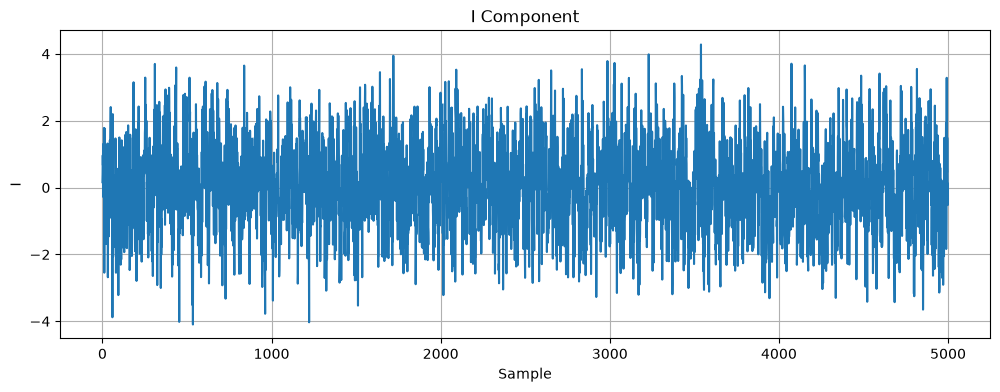

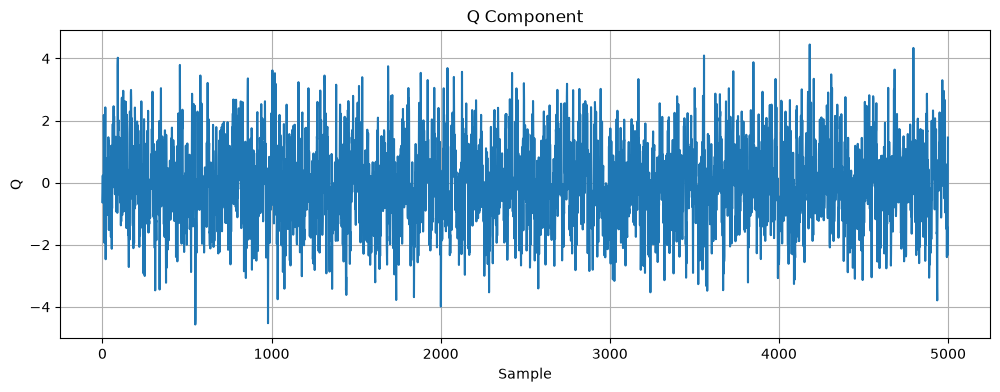

In [16]:
N_plot = 5000

plt.figure(figsize=(12, 4))
plt.plot(I[:N_plot])
plt.xlabel("Sample")
plt.ylabel("I")
plt.title("I Component")
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(Q[:N_plot])
plt.xlabel("Sample")
plt.ylabel("Q")
plt.title("Q Component")
plt.grid()
plt.show()

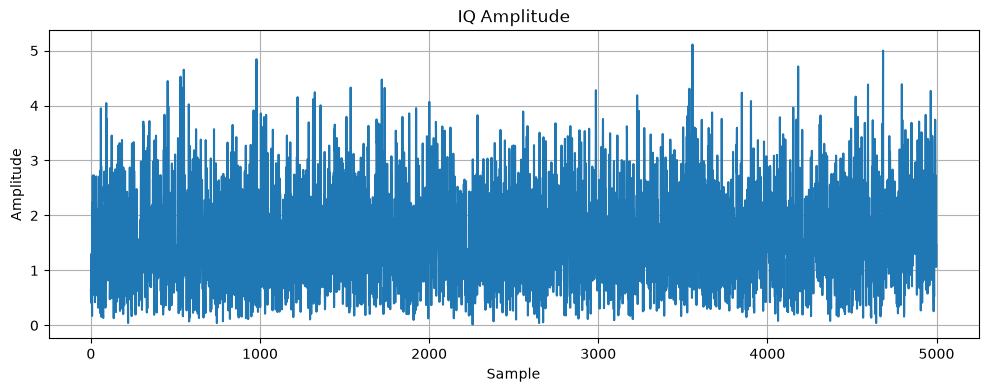

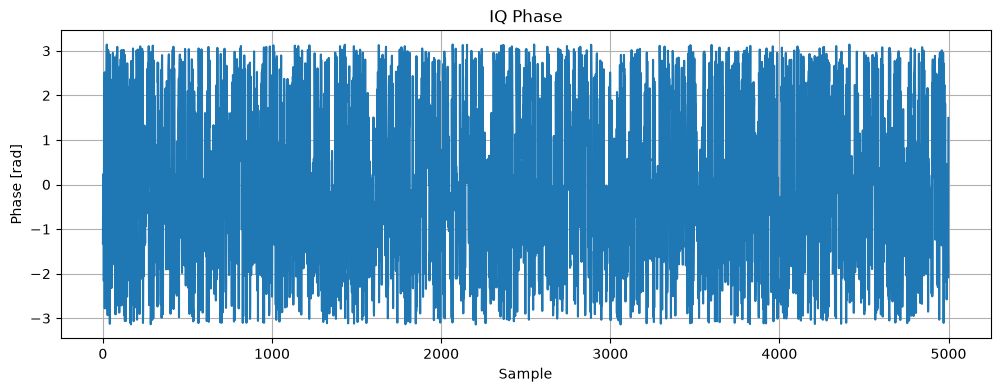

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(amplitude[:N_plot])
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("IQ Amplitude")
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(phase[:N_plot])
plt.xlabel("Sample")
plt.ylabel("Phase [rad]")
plt.title("IQ Phase")
plt.grid()
plt.show()

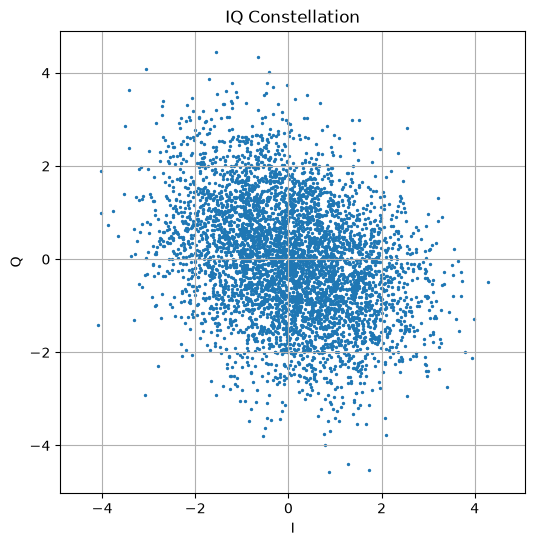

In [18]:
plt.figure(figsize=(6, 6))

plt.scatter(
    I[:N_plot],
    Q[:N_plot],
    s=2
)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("IQ Constellation")
plt.grid()
plt.axis("equal")

plt.show()